# Comparative Analysis: LMU vs S4 Across Multiple Datasets and Training Fractions

## Purpose

This notebook compares **Legendre Memory Units (LMU)** and **Structured State Space Sequence Models (S4)** to identify regimes where each model excels:

- **Sequence length**: Short vs long sequences
- **Dataset size**: Full dataset vs limited training fractions
- **Training fraction**: Performance across different data availability levels
- **Task type**: Classification, regression, forecasting

We use **task-specific primary metrics** (accuracy, F1, MAE) and analyze **relative performance gaps Δ** between the models.


In [1]:
from pathlib import Path
from typing import Dict, Any
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

current_dir = Path.cwd()
RESULTS_ROOT = current_dir.parent

MODELS = ["lmu", "s4"]
FRACTIONS = [0.1, 0.25, 0.5, 1.0]

DATASET_META: Dict[str, Dict[str, Any]] = {
    "psmnist": {
        "task_type": "multiclass",
        "primary_metric": "accuracy",
        "higher_is_better": True,
        "seq_len": 784,
        "notes": "Permuted Sequential MNIST"
    },
    "listops": {
        "task_type": "multiclass",
        "primary_metric": "accuracy",
        "higher_is_better": True,
        "seq_len": 2000,
        "notes": "ListOps - Long Range Arena"
    },
    "esc50": {
        "task_type": "multiclass",
        "primary_metric": "accuracy",
        "higher_is_better": True,
        "seq_len": 500,
        "notes": "Environmental Sound Classification"
    },
    "ppg": {
        "task_type": "regression",
        "primary_metric": "mae",
        "higher_is_better": False,
        "seq_len": 800,
        "notes": "PPG heart rate estimation"
    },
    "ptbxl": {
        "task_type": "multilabel",
        "primary_metric": "micro_f1",
        "higher_is_better": True,
        "seq_len": 1000,
        "notes": "PTB-XL ECG classification"
    },
    "qqp": {
        "task_type": "binary",
        "primary_metric": "f1_score",
        "higher_is_better": True,
        "seq_len": 129,
        "notes": "Quora Question Pairs"
    },
    "etts": {
        "task_type": "forecasting",
        "primary_metric": "mae",
        "higher_is_better": False,
        "seq_len": 96,
        "subdatasets": ["etth1", "etth2", "ettm1", "ettm2"],
        "notes": "Electricity Transformer Temperature - 4 variants"
    }
}

# Derive dataset list from metadata
DATASETS = list(DATASET_META.keys())

FIGURES_DIR = Path("./research_outputs/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({'font.size': 11, 'figure.dpi': 100, 'savefig.dpi': 300})

In [2]:
def primary_metric_value(result_dict: Dict[str, Any], dataset_name: str) -> float:
    """
    Extract primary metric value for a dataset from results dictionary.

    Args:
        result_dict: Test results dictionary
        dataset_name: Dataset name

    Returns:
        Primary metric value

    Raises:
        KeyError: If dataset not in DATASET_META
        ValueError: If metric not found in results
    """
    if dataset_name not in DATASET_META:
        raise KeyError(f"Unknown dataset: {dataset_name}")

    meta = DATASET_META[dataset_name]
    metric = meta['primary_metric']

    # PTB-XL: accept both micro_f1 and f1_micro
    if dataset_name == "ptbxl":
        return float(result_dict.get("micro_f1") or result_dict.get("f1_micro"))

    # QQP: f1_score
    if dataset_name == "qqp":
        if "f1_score" not in result_dict:
            raise ValueError(f"QQP missing f1_score. Found: {list(result_dict.keys())}")
        return float(result_dict["f1_score"])

    # Regression/forecasting: mae
    if meta["task_type"] in ["regression", "forecasting"]:
        if "mae" in result_dict:
            return float(result_dict["mae"])
        if "MAE" in result_dict:
            return float(result_dict["MAE"])
        raise ValueError(f"{dataset_name} missing mae. Found: {list(result_dict.keys())}")

    # Standard extraction
    if metric not in result_dict:
        raise ValueError(f"{dataset_name} missing {metric}. Found: {list(result_dict.keys())}")
    return float(result_dict[metric])


### load results

In [10]:
def load_results() -> pd.DataFrame:
    """Load test results using pattern: {dataset}/runs/{dataset}_{model}_task[_{subdataset}][_frac_{pct}]"""
    results = []

    for dataset in DATASET_META.keys():
        dataset_dir = current_dir / dataset
        meta = DATASET_META[dataset]

        # Get subdatasets if they exist, otherwise use [None] for single dataset
        subdatasets = meta.get("subdatasets", [None])

        for subdataset in subdatasets:
            for model in MODELS:
                for frac in FRACTIONS:
                    # Build run name based on pattern
                    if subdataset:
                        # Has subdataset: {dataset}_{model}_task_{subdataset}[_frac_{pct}]
                        if frac == 1.0:
                            run_name = f"{dataset}_{model}_task_{subdataset}"
                        else:
                            run_name = f"{dataset}_{model}_task_{subdataset}_frac_{int(frac*100)}"
                    else:
                        # No subdataset: {dataset}_{model}_task[_frac_{pct}]
                        if frac == 1.0:
                            run_name = f"{dataset}_{model}_task"
                        else:
                            run_name = f"{dataset}_{model}_task_frac_{int(frac*100)}"

                    test_file = dataset_dir / "runs" / run_name / "test_results.json"

                    if not test_file.exists():
                        continue

                    try:
                        with open(test_file) as f:
                            data = json.load(f)

                        results.append({
                            'dataset': dataset,
                            'subdataset': subdataset,
                            'model': model,
                            'fraction': frac,
                            'primary_metric_value': primary_metric_value(data, dataset),
                            'primary_metric_name': meta['primary_metric'],
                            'seq_len': meta['seq_len']
                        })
                    except Exception as e:
                        print(f"Error loading {test_file}: {e}")

    return pd.DataFrame(results)

# Load data
print("Loading results...")
results_df = load_results()
print(f"✓ Loaded {len(results_df)} results\n")

# Summary
for dataset in DATASETS:
    subset = results_df[results_df['dataset'] == dataset]
    if len(subset) == 0:
        continue

    # Check if dataset has subdatasets
    if DATASET_META[dataset].get("subdatasets"):
        print(f"{dataset:12s}: {len(subset):3d} results")
        for subdataset in subset['subdataset'].unique():
            if pd.notna(subdataset):
                count = len(subset[subset['subdataset'] == subdataset])
                print(f"  {subdataset:10s}: {count:3d} results")
    else:
        print(f"{dataset:12s}: {len(subset):3d} results")


Loading results...
✓ Loaded 80 results

psmnist     :   8 results
listops     :   8 results
esc50       :   8 results
ppg         :   8 results
ptbxl       :   8 results
qqp         :   8 results
etts        :  32 results
  etth1     :   8 results
  etth2     :   8 results
  ettm1     :   8 results
  ettm2     :   8 results


## Compute Performance Gaps (Δ)


In [16]:
def compute_delta(df: pd.DataFrame) -> pd.DataFrame:
    """Compute Δ = LMU - S4 (positive means LMU better)."""
    results = []

    # Fill NaN subdataset with empty string for grouping
    df_copy = df.copy()
    df_copy['subdataset'] = df_copy['subdataset'].fillna('')

    # Group by (dataset, subdataset, fraction)
    for (dataset, subdataset, fraction), group in df_copy.groupby(['dataset', 'subdataset', 'fraction']):
        lmu = group[group['model'] == 'lmu']
        s4 = group[group['model'] == 's4']

        if len(lmu) == 0 or len(s4) == 0:
            continue

        lmu_val = lmu['primary_metric_value'].mean()
        s4_val = s4['primary_metric_value'].mean()

        # Compute delta (positive = LMU better)
        higher_is_better = DATASET_META[dataset]['higher_is_better']
        delta = (lmu_val - s4_val) if higher_is_better else (s4_val - lmu_val)

        # Create display name: for subdatasets, use "dataset_subdataset"
        if subdataset:  # subdataset is not empty string
            display_name = f"{dataset}_{subdataset}"
        else:
            display_name = dataset

        results.append({
            'dataset': display_name,
            'base_dataset': dataset,
            'subdataset': subdataset if subdataset else None,
            'fraction': fraction,
            'lmu_value': lmu_val,
            's4_value': s4_val,
            'delta': delta,
            'task_type': DATASET_META[dataset]['task_type'],
            'seq_len': DATASET_META[dataset]['seq_len']
        })

    return pd.DataFrame(results)

delta_df = compute_delta(results_df)

# Print summary
if len(delta_df) > 0:
    print("\nPerformance Gaps (Δ > 0 means LMU better):\n")
    for dataset in delta_df['dataset'].unique():
        print(f"\n{dataset.upper()}:")
        subset = delta_df[delta_df['dataset'] == dataset].sort_values('fraction')
        for _, row in subset.iterrows():
            sign = "GREEN" if row['delta'] > 0 else "BLUE"
            print(f"  {row['fraction']*100:5.0f}%: Δ={row['delta']:+.4f} {sign}")

    # Create and display pivot table
    print("\n" + "="*60)
    print("DELTA MATRIX (Dataset × Fraction)")
    print("="*60)
    pivot_df = delta_df.pivot(index='dataset', columns='fraction', values='delta')
    pivot_df = pivot_df[sorted(pivot_df.columns)]
    print(pivot_df.to_string())
    print("="*60)
else:
    print("\n No performance gaps to analyze - missing LMU or S4 results")
    pivot_df = pd.DataFrame()  # Empty DataFrame to avoid errors later



Performance Gaps (Δ > 0 means LMU better):


ESC50:
     10%: Δ=-0.0225 BLUE
     25%: Δ=-0.0525 BLUE
     50%: Δ=-0.0550 BLUE
    100%: Δ=-0.0650 BLUE

ETTS_ETTH1:
     10%: Δ=+0.0054 GREEN
     25%: Δ=+0.0004 GREEN
     50%: Δ=+0.0005 GREEN
    100%: Δ=-0.0066 BLUE

ETTS_ETTH2:
     10%: Δ=-0.0140 BLUE
     25%: Δ=-0.0050 BLUE
     50%: Δ=+0.0192 GREEN
    100%: Δ=+0.0529 GREEN

ETTS_ETTM1:
     10%: Δ=+0.0053 GREEN
     25%: Δ=+0.0001 GREEN
     50%: Δ=-0.0178 BLUE
    100%: Δ=-0.0286 BLUE

ETTS_ETTM2:
     10%: Δ=-0.0058 BLUE
     25%: Δ=+0.0118 GREEN
     50%: Δ=+0.0140 GREEN
    100%: Δ=-0.0168 BLUE

LISTOPS:
     10%: Δ=+0.0015 GREEN
     25%: Δ=-0.0005 BLUE
     50%: Δ=+0.0020 GREEN
    100%: Δ=-0.0355 BLUE

PPG:
     10%: Δ=+3.3962 GREEN
     25%: Δ=+5.2206 GREEN
     50%: Δ=+0.4440 GREEN
    100%: Δ=-1.9557 BLUE

PSMNIST:
     10%: Δ=+0.1743 GREEN
     25%: Δ=+0.0656 GREEN
     50%: Δ=+0.0275 GREEN
    100%: Δ=+0.0458 GREEN

PTBXL:
     10%: Δ=-0.0193 BLUE
     25%: Δ=-0.021

## Grouped Analysis



By Task Type:
----------------------------------------
multiclass     : Δ=+0.0071 GREEN (LMU wins 6/12)
forecasting    : Δ=+0.0009 GREEN (LMU wins 9/16)
regression     : Δ=+1.7763 GREEN (LMU wins 3/4)
multilabel     : Δ=-0.0227 BLUE (LMU wins 0/4)
binary         : Δ=-0.0195 BLUE (LMU wins 1/4)

By Sequence Length:
----------------------------------------
short          : Δ=-0.0031 BLUE (LMU wins 10/20)
medium         : Δ=+0.6019 GREEN (LMU wins 7/12)
long           : Δ=-0.0154 BLUE (LMU wins 2/8)


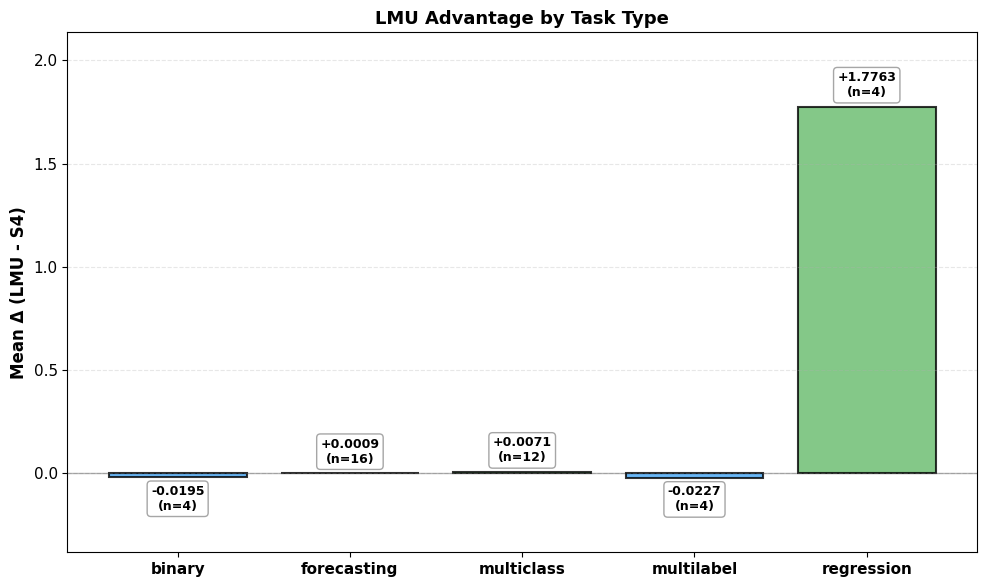

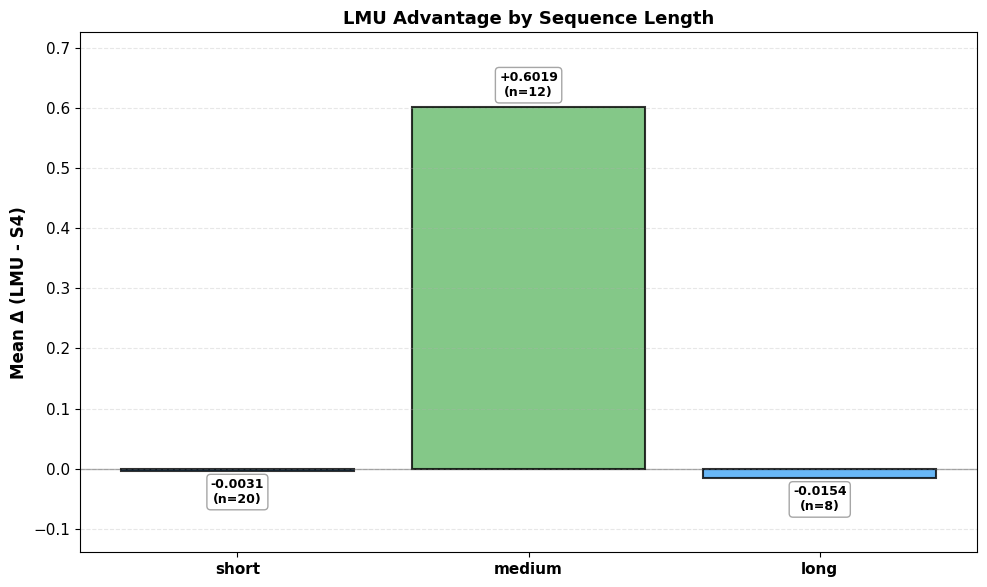


✓ Saved grouped analysis charts


In [12]:
def add_seq_len_bucket(df: pd.DataFrame) -> pd.DataFrame:
    """Add sequence length bucket column."""
    df = df.copy()
    def categorize(seq_len):
        if pd.isna(seq_len):
            return 'unknown'
        elif seq_len < 200:
            return 'short'
        elif seq_len < 1000:
            return 'medium'
        elif seq_len < 5000:
            return 'long'
        else:
            return 'very_long'
    df['seq_len_bucket'] = df['seq_len'].apply(categorize)
    return df

delta_df_enhanced = add_seq_len_bucket(delta_df)

# Aggregate by task type
print("\nBy Task Type:")
print("-" * 40)
for task_type in delta_df_enhanced['task_type'].unique():
    subset = delta_df_enhanced[delta_df_enhanced['task_type'] == task_type]
    mean_delta = subset['delta'].mean()
    lmu_wins = (subset['delta'] > 0).sum()
    total = len(subset)
    sign = "GREEN" if mean_delta > 0 else "BLUE"
    print(f"{task_type:15s}: Δ={mean_delta:+.4f} {sign} (LMU wins {lmu_wins}/{total})")

# Aggregate by sequence length
print("\nBy Sequence Length:")
print("-" * 40)
for bucket in ['short', 'medium', 'long', 'very_long', 'unknown']:
    subset = delta_df_enhanced[delta_df_enhanced['seq_len_bucket'] == bucket]
    if len(subset) == 0:
        continue
    mean_delta = subset['delta'].mean()
    lmu_wins = (subset['delta'] > 0).sum()
    total = len(subset)
    sign = "GREEN" if mean_delta > 0 else "BLUE"
    print(f"{bucket:15s}: Δ={mean_delta:+.4f} {sign} (LMU wins {lmu_wins}/{total})")

# Bar chart by task type
fig, ax = plt.subplots(figsize=(10, 6))
task_stats = delta_df_enhanced.groupby('task_type')['delta'].agg(['mean', 'count'])
colors = ['#66BB6A' if m > 0 else '#42A5F5' for m in task_stats['mean']]
bars = ax.bar(range(len(task_stats)), task_stats['mean'], color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax.axhline(0, color='black', linewidth=1, alpha=0.3)

# Calculate y-axis limits to show all bars clearly
min_val = task_stats['mean'].min()
max_val = task_stats['mean'].max()
data_range = max_val - min_val

# Add padding (20% on each side)
if data_range > 0:
    y_padding = data_range * 0.2
    ax.set_ylim(min_val - y_padding, max_val + y_padding)

ax.set_xticks(range(len(task_stats)))
ax.set_xticklabels(task_stats.index, fontweight='bold', rotation=0)
ax.set_ylabel('Mean Δ (LMU - S4)', fontweight='bold', fontsize=12)
ax.set_title('LMU Advantage by Task Type', fontweight='bold', fontsize=13)
ax.grid(True, axis='y', alpha=0.3, linestyle='--')

# Improved annotations with better positioning
for i, (bar, val, cnt) in enumerate(zip(bars, task_stats['mean'], task_stats['count'])):
    height = bar.get_height()

    # Position text above or below bar based on available space
    if height > 0:
        y_pos = height
        va = 'bottom'
        offset = 0.02 * (max_val - min_val) if data_range > 0 else 0.01
    else:
        y_pos = height
        va = 'top'
        offset = -0.02 * (max_val - min_val) if data_range > 0 else -0.01

    ax.text(bar.get_x() + bar.get_width()/2, y_pos + offset,
            f'{val:+.4f}\n(n={int(cnt)})',
            ha='center', va=va, fontsize=9, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.7))

plt.tight_layout()
plt.savefig(FIGURES_DIR / "grouped_task_type.png", dpi=300, bbox_inches='tight')
plt.show()

# Bar chart by sequence length
seq_stats = delta_df_enhanced.groupby('seq_len_bucket')['delta'].agg(['mean', 'count'])
# Only select buckets that actually exist in the data
bucket_order = ['short', 'medium', 'long', 'very_long', 'unknown']
existing_buckets = [b for b in bucket_order if b in seq_stats.index]
if existing_buckets:
    seq_stats = seq_stats.loc[existing_buckets]

if len(seq_stats) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['#66BB6A' if m > 0 else '#42A5F5' for m in seq_stats['mean']]
    bars = ax.bar(range(len(seq_stats)), seq_stats['mean'], color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.axhline(0, color='black', linewidth=1, alpha=0.3)

    # Calculate y-axis limits to show all bars clearly
    min_val = seq_stats['mean'].min()
    max_val = seq_stats['mean'].max()
    data_range = max_val - min_val

    # Add padding (20% on each side)
    if data_range > 0:
        y_padding = data_range * 0.2
        ax.set_ylim(min_val - y_padding, max_val + y_padding)

    ax.set_xticks(range(len(seq_stats)))
    ax.set_xticklabels(seq_stats.index, fontweight='bold', rotation=0)
    ax.set_ylabel('Mean Δ (LMU - S4)', fontweight='bold', fontsize=12)
    ax.set_title('LMU Advantage by Sequence Length', fontweight='bold', fontsize=13)
    ax.grid(True, axis='y', alpha=0.3, linestyle='--')

    # Improved annotations with better positioning
    for i, (bar, val, cnt) in enumerate(zip(bars, seq_stats['mean'], seq_stats['count'])):
        height = bar.get_height()

        # Position text above or below bar based on available space
        if height > 0:
            y_pos = height
            va = 'bottom'
            offset = 0.02 * (max_val - min_val) if data_range > 0 else 0.01
        else:
            y_pos = height
            va = 'top'
            offset = -0.02 * (max_val - min_val) if data_range > 0 else -0.01

        ax.text(bar.get_x() + bar.get_width()/2, y_pos + offset,
                f'{val:+.4f}\n(n={int(cnt)})',
                ha='center', va=va, fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.7))

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "grouped_seq_len.png", dpi=300, bbox_inches='tight')
    plt.show()

print(f"\n✓ Saved grouped analysis charts")


## Visualization


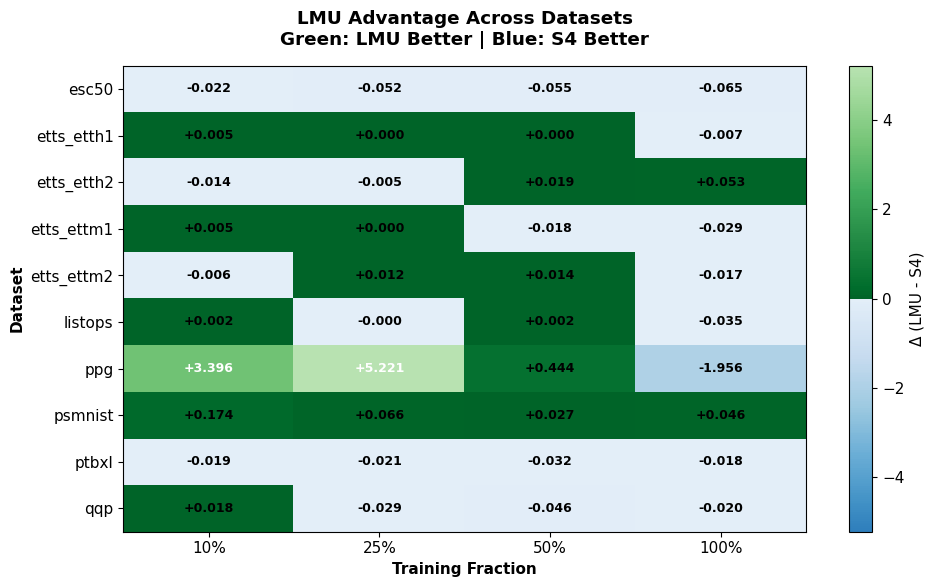


✓ Saved heatmap to research_outputs/figures/delta_heatmap.png


In [13]:
if len(pivot_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))

    vmax = np.nanmax(np.abs(pivot_df.values))
    colors_blue = plt.cm.Blues_r(np.linspace(0.3, 0.9, 128))
    colors_green = plt.cm.Greens(np.linspace(0.9, 0.3, 128))
    cmap = mcolors.LinearSegmentedColormap.from_list('diverging', np.vstack((colors_blue, colors_green)))

    im = ax.imshow(pivot_df.values, cmap=cmap, aspect='auto', vmin=-vmax, vmax=vmax)

    # Labels
    fractions = [f"{f*100:.0f}%" for f in pivot_df.columns]
    ax.set_xticks(range(len(fractions)))
    ax.set_yticks(range(len(pivot_df.index)))
    ax.set_xticklabels(fractions)
    ax.set_yticklabels(pivot_df.index)

    # Annotate cells
    for i in range(len(pivot_df.index)):
        for j in range(len(pivot_df.columns)):
            val = pivot_df.values[i, j]
            if not np.isnan(val):
                color = 'white' if abs(val) > vmax * 0.5 else 'black'
                ax.text(j, i, f'{val:+.3f}', ha='center', va='center', color=color, fontsize=9, fontweight='bold')

    plt.colorbar(im, ax=ax, label='Δ (LMU - S4)')
    ax.set_xlabel('Training Fraction', fontweight='bold')
    ax.set_ylabel('Dataset', fontweight='bold')
    ax.set_title('LMU Advantage Across Datasets\nGreen: LMU Better | Blue: S4 Better', fontweight='bold', pad=15)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "delta_heatmap.png", dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n✓ Saved heatmap to {FIGURES_DIR}/delta_heatmap.png")
else:
    print("\n  Skipping heatmap - no data available")


## Per-Dataset Plots


In [14]:
plot_datasets = []
for dataset in DATASETS:
    if DATASET_META[dataset].get("subdatasets"):
        for subdataset in DATASET_META[dataset]["subdatasets"]:
            plot_datasets.append((dataset, subdataset, f"{dataset}_{subdataset}"))
    else:
        plot_datasets.append((dataset, None, dataset))

for dataset, subdataset, display_name in plot_datasets:
    if subdataset:
        subset = results_df[(results_df['dataset'] == dataset) & (results_df['subdataset'] == subdataset)]
    else:
        subset = results_df[(results_df['dataset'] == dataset) & (results_df['subdataset'].isna())]

    if len(subset) == 0:
        continue

    fig, ax = plt.subplots(figsize=(8, 5))

    for model in MODELS:
        data = subset[subset['model'] == model].sort_values('fraction')
        if len(data) == 0:
            continue

        color = '#2E7D32' if model == 'lmu' else '#1565C0'
        marker = 'o' if model == 'lmu' else 's'
        ax.plot(data['fraction'] * 100, data['primary_metric_value'],
                marker=marker, label=model.upper(), color=color, linewidth=2, markersize=8)

    metric = DATASET_META[dataset]['primary_metric']
    direction = "↑" if DATASET_META[dataset]['higher_is_better'] else "↓"

    ax.set_xlabel('Training Fraction (%)', fontweight='bold')
    ax.set_ylabel(metric.upper(), fontweight='bold')
    ax.set_title(f'{display_name.upper()}: {metric} {direction}', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"{display_name}_comparison.png", dpi=300, bbox_inches='tight')
    plt.close()

print(f"\n✓ Saved {len(plot_datasets)} comparison plots")



✓ Saved 10 comparison plots


## Summary


In [15]:
print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)
print(f"\nResults: {len(results_df)} experiments loaded")
print(f"Datasets: {len(results_df['dataset'].unique())}")
print(f"Figures: {len(list(FIGURES_DIR.glob('*.png')))} saved to {FIGURES_DIR}")

# Win rates
lmu_wins = (delta_df['delta'] > 0).sum()
s4_wins = (delta_df['delta'] < 0).sum()
total = len(delta_df)

print(f"\nWin Rates:")
if total > 0:
    print(f"  GREEN - LMU: {lmu_wins}/{total} ({lmu_wins/total*100:.1f}%)")
    print(f"  BLUE - S4:  {s4_wins}/{total} ({s4_wins/total*100:.1f}%)")
else:
    print(f"  No comparisons available")

print("\n" + "="*60)



ANALYSIS COMPLETE

Results: 80 experiments loaded
Datasets: 7
Figures: 13 saved to research_outputs/figures

Win Rates:
  GREEN - LMU: 19/40 (47.5%)
  BLUE - S4:  21/40 (52.5%)



## Export Results


In [11]:
from datetime import datetime

# Create output directory
OUTPUT_DIR = Path("./research_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("\n" + "="*60)
print("EXPORTING RESULTS")
print("="*60)

# 1. Save parsed results DataFrame to CSV
if len(results_df) > 0:
    csv_path = OUTPUT_DIR / "parsed_results.csv"
    results_df.to_csv(csv_path, index=False)
    print(f"\n✓ Saved parsed results to: {csv_path}")
    print(f"  {len(results_df)} rows × {len(results_df.columns)} columns")

# 2. Save delta DataFrame to CSV
if len(delta_df) > 0:
    delta_csv_path = OUTPUT_DIR / "delta_results.csv"
    delta_df.to_csv(delta_csv_path, index=False)
    print(f"\n✓ Saved delta results to: {delta_csv_path}")
    print(f"  {len(delta_df)} rows × {len(delta_df.columns)} columns")

# 3. Generate Markdown Summary Report
if len(delta_df) > 0:
    summary_path = OUTPUT_DIR / "summary.md"

    with open(summary_path, 'w') as f:
        # Header
        f.write("# LMU vs S4 Comparative Analysis - Summary Report\n\n")
        f.write(f"**Generated**: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
        f.write("---\n\n")

        # Dataset Coverage Table
        f.write("## Dataset Coverage\n\n")
        f.write("| Dataset | LMU Results | S4 Results | Total | Fractions |\n")
        f.write("|---------|-------------|------------|-------|----------|\n")

        for dataset in sorted(results_df['dataset'].unique()):
            subset = results_df[results_df['dataset'] == dataset]
            lmu_count = len(subset[subset['model'] == 'lmu'])
            s4_count = len(subset[subset['model'] == 's4'])
            total_count = len(subset)
            fractions = sorted(subset['fraction'].unique())
            frac_str = ", ".join([f"{f*100:.0f}%" for f in fractions])
            f.write(f"| {dataset} | {lmu_count} | {s4_count} | {total_count} | {frac_str} |\n")

        f.write(f"\n**Total**: {len(results_df)} experiments across {len(results_df['dataset'].unique())} datasets\n\n")

        # Top-5 LMU Wins
        f.write("---\n\n")
        f.write("## Top-5 LMU Wins (by absolute Δ)\n\n")
        f.write("| Rank | Dataset | Fraction | Δ | LMU Value | S4 Value |\n")
        f.write("|------|---------|----------|---|-----------|----------|\n")

        lmu_wins_df = delta_df[delta_df['delta'] > 0].copy()
        lmu_wins_df['abs_delta'] = lmu_wins_df['delta'].abs()
        top_lmu = lmu_wins_df.nlargest(5, 'abs_delta')

        for idx, (rank, row) in enumerate(top_lmu.iterrows(), 1):
            f.write(f"| {rank} | {row['dataset']} | {row['fraction']*100:.0f}% | "
                   f"+{row['delta']:.4f} | {row['lmu_value']:.4f} | {row['s4_value']:.4f} |\n")

        if len(top_lmu) == 0:
            f.write("| - | No LMU wins | - | - | - | - |\n")

        # Top-5 S4 Wins
        f.write("\n## Top-5 S4 Wins (by absolute Δ)\n\n")
        f.write("| Rank | Dataset | Fraction | Δ | S4 Value | LMU Value |\n")
        f.write("|------|---------|----------|---|----------|----------|\n")

        s4_wins_df = delta_df[delta_df['delta'] < 0].copy()
        s4_wins_df['abs_delta'] = s4_wins_df['delta'].abs()
        top_s4 = s4_wins_df.nlargest(5, 'abs_delta')

        for idx, (rank, row) in enumerate(top_s4.iterrows(), 1):
            f.write(f"| {rank} | {row['dataset']} | {row['fraction']*100:.0f}% | "
                   f"{row['delta']:.4f} | {row['s4_value']:.4f} | {row['lmu_value']:.4f} |\n")

        if len(top_s4) == 0:
            f.write("| - | No S4 wins | - | - | - | - |\n")

        # Per-Task-Type Analysis
        if 'task_type' in delta_df.columns:
            f.write("\n---\n\n")
            f.write("## Performance by Task Type\n\n")
            f.write("| Task Type | Mean Δ @ 10% | Mean Δ @ 100% | Change | Count |\n")
            f.write("|-----------|--------------|---------------|--------|-------|\n")

            for task_type in sorted(delta_df['task_type'].unique()):
                subset = delta_df[delta_df['task_type'] == task_type]

                # At 10%
                at_10 = subset[subset['fraction'] == 0.1]
                mean_10 = at_10['delta'].mean() if len(at_10) > 0 else float('nan')

                # At 100%
                at_100 = subset[subset['fraction'] == 1.0]
                mean_100 = at_100['delta'].mean() if len(at_100) > 0 else float('nan')

                # Change
                if pd.notna(mean_10) and pd.notna(mean_100):
                    change = mean_100 - mean_10
                    change_str = f"{change:+.4f}"
                else:
                    change_str = "N/A"

                mean_10_str = f"{mean_10:+.4f}" if pd.notna(mean_10) else "N/A"
                mean_100_str = f"{mean_100:+.4f}" if pd.notna(mean_100) else "N/A"

                f.write(f"| {task_type} | {mean_10_str} | {mean_100_str} | {change_str} | {len(subset)} |\n")

        # Per-Sequence-Length Analysis
        if 'seq_len_bucket' in delta_df_enhanced.columns:
            f.write("\n---\n\n")
            f.write("## Performance by Sequence Length\n\n")
            f.write("| Seq Length | Mean Δ @ 10% | Mean Δ @ 100% | Change | Count |\n")
            f.write("|------------|--------------|---------------|--------|-------|\n")

            bucket_order = ['short', 'medium', 'long', 'very_long', 'unknown']
            for bucket in bucket_order:
                subset = delta_df_enhanced[delta_df_enhanced['seq_len_bucket'] == bucket]
                if len(subset) == 0:
                    continue

                # At 10%
                at_10 = subset[subset['fraction'] == 0.1]
                mean_10 = at_10['delta'].mean() if len(at_10) > 0 else float('nan')

                # At 100%
                at_100 = subset[subset['fraction'] == 1.0]
                mean_100 = at_100['delta'].mean() if len(at_100) > 0 else float('nan')

                # Change
                if pd.notna(mean_10) and pd.notna(mean_100):
                    change = mean_100 - mean_10
                    change_str = f"{change:+.4f}"
                else:
                    change_str = "N/A"

                mean_10_str = f"{mean_10:+.4f}" if pd.notna(mean_10) else "N/A"
                mean_100_str = f"{mean_100:+.4f}" if pd.notna(mean_100) else "N/A"

                f.write(f"| {bucket} | {mean_10_str} | {mean_100_str} | {change_str} | {len(subset)} |\n")

        # Overall Statistics
        f.write("\n---\n\n")
        f.write("## Overall Statistics\n\n")
        f.write(f"- **Total Comparisons**: {len(delta_df)}\n")
        f.write(f"- **LMU Wins**: {lmu_wins} ({lmu_wins/total*100:.1f}%)\n" if total > 0 else "- **LMU Wins**: 0 (0.0%)\n")
        f.write(f"- **S4 Wins**: {s4_wins} ({s4_wins/total*100:.1f}%)\n" if total > 0 else "- **S4 Wins**: 0 (0.0%)\n")
        f.write(f"- **Mean Δ (all)**: {delta_df['delta'].mean():+.4f}\n")
        f.write(f"- **Median Δ (all)**: {delta_df['delta'].median():+.4f}\n")
        f.write(f"- **Std Δ (all)**: {delta_df['delta'].std():.4f}\n")

        # Footer
        f.write("\n---\n\n")
        f.write("*Δ > 0 indicates LMU performs better; Δ < 0 indicates S4 performs better*\n")

    print(f"\n✓ Saved markdown summary to: {summary_path}")

print("\n" + "="*60)
print("EXPORT COMPLETE")
print("="*60)


EXPORTING RESULTS

✓ Saved parsed results to: research_outputs/parsed_results.csv
  80 rows × 7 columns

✓ Saved delta results to: research_outputs/delta_results.csv
  40 rows × 9 columns

✓ Saved markdown summary to: research_outputs/summary.md

EXPORT COMPLETE
